# 2. Data Acquisition And Understanding

## 2.1 Import Library, Load, and Understanding the Dataset

The **[Saudi Arabia Used Cars](https://www.kaggle.com/datasets/turkibintalib/saudi-arabia-used-cars-dataset)** dataset on Kaggle contains approximately **8,248 used car records** collected from the *syarah.com* website. Each entry includes information such as **brand, model, year, color, fuel type, transmission, mileage, location, and price**.  

This dataset is commonly used for **used car market trend analysis in Saudi Arabia** as well as for building **machine learning–based car price prediction models**.  

On the website, there is an English version of the dataset that is uncleaned; therefore, in this case, the dataset used will be that version.

In [1]:
# Import library dan load dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Load dataset
data_path = '../Datasets/UsedCarsSA_Unclean_EN.csv'
real_df = pd.read_csv(data_path)
df = real_df.copy()
df.head()

,Link,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Condition,Mileage,Region,Price,Negotiable
0,https://syarah.com/%D9%83%D8%B1%D8%A7%D9%8A%D8...,Chrysler,C300,2018,Saudi,Black,Full,5.7,Gas,Automatic,Used,103000,Riyadh,114000,False
1,https://syarah.com/%D9%86%D9%8A%D8%B3%D8%A7%D9...,Nissan,Patrol,2016,Saudi,White,Full,4.8,Gas,Automatic,Used,5448,Riyadh,Negotiable,True
2,https://syarah.com/online/%D9%86%D9%8A%D8%B3%D...,Nissan,Sunny,2019,Saudi,Silver,Standard,1.5,Gas,Automatic,Used,72418,Riyadh,27500,False
3,https://syarah.com/online/%D9%87%D9%88%D9%86%D...,Hyundai,Elantra,2019,Saudi,Grey,Standard,1.6,Gas,Automatic,Used,114154,Riyadh,43000,False
4,https://syarah.com/online/%D9%87%D9%88%D9%86%D...,Hyundai,Elantra,2019,Saudi,Silver,Semi Full,2.0,Gas,Automatic,Used,41912,Riyadh,59500,False


Here is the **column description** for the **[Saudi Arabia Used Cars](https://www.kaggle.com/datasets/turkibintalib/saudi-arabia-used-cars-dataset)** dataset:

* **Link** — A link to the car advertisement page on the *syarah.com* website.  
* **Make** — The car manufacturer or brand name.  
* **Type** — The type or model of the used car.  
* **Year** — The year the car was manufactured.  
* **Origin** — The origin or country where the car was produced.  
* **Color** — The color of the car.  
* **Options** — Features or additional options available in the car.  
* **Engine_Size** — The engine size or capacity of the car.  
* **Fuel_Type** — The type of fuel used by the car.  
* **Gear_Type** — The car’s transmission type (manual or automatic).  
* **Condition** — The condition of the car (e.g., new, lightly used, or heavily used).  
* **Mileage** — The distance the car has traveled (usually in kilometers).  
* **Region** — The region or city where the car is being sold in Saudi Arabia.  
* **Price** — The car’s selling price in local currency (SAR).  
* **Negotiable** — Indicates whether the price is negotiable (yes/no).

## 2.2 Quick Data Health Check

### 2.2.1 Viewing Data Types

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8248 entries, 0 to 8247
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Link         8248 non-null   object 
 1   Make         8248 non-null   object 
 2   Type         8248 non-null   object 
 3   Year         8248 non-null   int64  
 4   Origin       8153 non-null   object 
 5   Color        8248 non-null   object 
 6   Options      8139 non-null   object 
 7   Engine_Size  5982 non-null   float64
 8   Fuel_Type    8248 non-null   object 
 9   Gear_Type    8174 non-null   object 
 10  Condition    8248 non-null   object 
 11  Mileage      8248 non-null   int64  
 12  Region       8248 non-null   object 
 13  Price        8248 non-null   object 
 14  Negotiable   8248 non-null   bool   
dtypes: bool(1), float64(1), int64(2), object(11)
memory usage: 910.3+ KB


### Dataset Overview

The dataset consists of **8,248 rows**, where each row represents **one used car** listed for sale. It contains **15 columns** with various information related to car specifications, condition, and price.

### Data Types and Column Content

* The dataset contains a **mix of text, numeric, and boolean data**.  
* Most columns are **text (object)** type, such as car brand, model, color, and selling region.  
* The main numeric columns include:

  * **Year**: the car’s production year  
  * **Mileage**: the distance the car has traveled  
  * **Engine_Size**: the engine capacity  

* The **Negotiable** column is boolean, indicating whether the price can still be negotiated.

### Data Completeness (Missing Values)

Some columns are not fully populated, including:

* **Engine_Size** → many missing values  
* **Options**, **Origin**, and **Gear_Type** → partially missing data  

This indicates that the dataset **requires data cleaning and missing value handling** before being used for analysis and modeling.

### 2.2.2 Descriptive Statistics

In [3]:
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Link,8248,8228,https://syarah.com/%D9%87%D9%88%D9%86%D8%AF%D8...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Make,8248,65,Toyota,2074,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,8248,435,Land Cruiser,374,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,8248.0,NaN,NaN,NaN,2014.014064,5.935349,1936.0,2012.0,2016.0,2018.0,2022.0
Origin,8153,3,Saudi,6084,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Color,8248,15,White,3574,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Options,8139,3,Full,3235,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Engine_Size,5982.0,NaN,NaN,NaN,3.175794,1.56748,1.0,2.0,2.7,4.0,9.0
Fuel_Type,8248,3,Gas,8051,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gear_Type,8174,2,Automatic,7069,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Based on the descriptive statistics, the dataset contains **8,248 used car records** with a diverse combination of numeric and categorical features. Below is a summary of the key findings.

#### Vehicle Overview

* The most frequent brand is **Toyota**, with the most common model being **Land Cruiser**.  
* Most cars were manufactured between **2016–2022**, with a **median year around 2018**, indicating that the majority of vehicles are relatively new.  
* All entries represent **used vehicles**.

#### Vehicle Specifications

* The **average engine capacity** is around **3.2 liters**, with a median of **2.7 liters**, and a wide variation up to **9.0 liters**, suggesting the presence of large-engine vehicles.  
* **Gasoline (Gas)** is the dominant fuel type.  
* **Automatic transmissions** are far more common than manual.  
* The most frequently observed car color is **white**.

#### Mileage

* The **average mileage** is approximately **149 thousand km**, with a median of about **102 thousand km**.  
* There are **extremely high mileage values** reaching tens of millions of kilometers, indicating potential **outliers or unrealistic data** that require special attention during data cleaning.

#### Location and Vehicle Origin

* Most cars are sold in **Riyadh**, followed by other regions in Saudi Arabia.  
* The majority of vehicles originate from the **Saudi domestic market**.

#### Price and Negotiation

* The **Price** column is still stored as text and contains values such as **“Negotiable”**, meaning it is **not yet ready to be used directly** as a numeric target.  
* About **one-third of the price data is negotiable**, indicating variation in pricing mechanisms within the market.  
* The **Negotiable** column shows that most cars are **not negotiable**, although a significant proportion remains flexible.

### 2.2.3 Viewing the Summary of Unique Values per Column

In [4]:
def unique_summary(frame, sample_size=5):
    result = []
    for col in frame.columns:
        uniques = frame[col].dropna().unique()
        result.append({
            'Column': col,
            'Unique Count': frame[col].nunique(),
            'Sample Unique': list(uniques[:sample_size])
        })
    return pd.DataFrame(result).sort_values('Unique Count', ascending=False).reset_index(drop=True)

unique_summary(df)

,Column,Unique Count,Sample Unique
0,Link,8228,[https://syarah.com/%D9%83%D8%B1%D8%A7%D9%8A%D...
1,Mileage,2196,"[103000, 5448, 72418, 114154, 41912]"
2,Price,549,"[114000, Negotiable, 27500, 43000, 59500]"
3,Type,435,"[C300, Patrol, Sunny, Elantra, Accord]"
4,Engine_Size,75,"[5.7, 4.8, 1.5, 1.6, 2.0]"
5,Make,65,"[Chrysler, Nissan, Hyundai, Honda, Toyota]"
6,Year,55,"[2018, 2016, 2019, 2011, 2009]"
7,Region,27,"[Riyadh, Jeddah, Dammam, Al-Medina, Qassim]"
8,Color,15,"[Black, White, Silver, Grey, Navy]"
9,Origin,3,"[Saudi, Gulf Arabic, Other]"


This analysis aims to understand **how diverse the values in each column are** and to identify the **role of each feature** within the dataset.

#### Columns with Very High Variability

* **Link** has nearly unique values in every row since each car has its own listing page.  
  ➜ **Not relevant for modeling**, serves only as a data identifier.  

* **Mileage** contains thousands of unique values, indicating highly varied vehicle usage.  
  ➜ **Important numeric feature** with strong influence on price.  

* **Price** has hundreds of variations, including text values such as *“Negotiable”*.  
  ➜ Requires **cleaning and numeric conversion** before being used as the target variable.  

#### Vehicle Specification Columns

* **Type** (hundreds of models) and **Make** (dozens of brands) show **vehicle diversity** in the market.  
  ➜ Highly informative, but requires **proper encoding** due to high cardinality.  

* **Engine_Size** and **Year** have reasonable variation and are relevant for price prediction.  

#### Location and Appearance Columns

* **Region** includes dozens of selling locations, with major cities such as Riyadh and Jeddah dominating.  
* **Color** has limited variation, with neutral colors like white and black being most common.  

#### Columns with Limited Categories

* **Origin**, **Options**, and **Fuel_Type** each contain only a few main categories.  
  ➜ Easy to process and potentially provide additional price signals.  

* **Gear_Type** and **Negotiable** are binary columns, making them **simple to analyze**.  

* **Condition** contains only a single value (*Used*), meaning it **does not add information** and can be considered for removal.

### 2.2.4 Viewing Missing Values

In [5]:
df.isnull().sum().sort_values(ascending=False)

Engine_Size    2266
Options         109
Origin           95
Gear_Type        74
Link              0
Make              0
Type              0
Year              0
Color             0
Fuel_Type         0
Condition         0
Mileage           0
Region            0
Price             0
Negotiable        0
dtype: int64

Based on the inspection results, most columns in the dataset **do not contain missing values**. Missing data appears only in a few specific columns.

#### Columns with Missing Data

* **Engine_Size** → **2,266 missing values**  
  This column has the highest number of missing entries. This is reasonable because engine capacity information is **not always provided** in used car listings.  

* **Options** → **109 missing values**  
  Indicates that vehicle feature details are not always filled in by sellers.  

* **Origin** → **95 missing values**  
  Some vehicles do not clearly specify their market origin.  

* **Gear_Type** → **74 missing values**  
  Transmission type information is unavailable for several cars.  

#### Columns Without Missing Data

Columns such as **Make, Type, Year, Color, Fuel_Type, Condition, Mileage, Region, Price, Negotiable, and Link** are **100% complete**, meaning they do not require special handling for missing values.

### 2.2.6 Checking Numeric Normality


📊 Skewness & Kurtosis Summary:


,skew,kurtosis
Year,-2.615889,12.729579


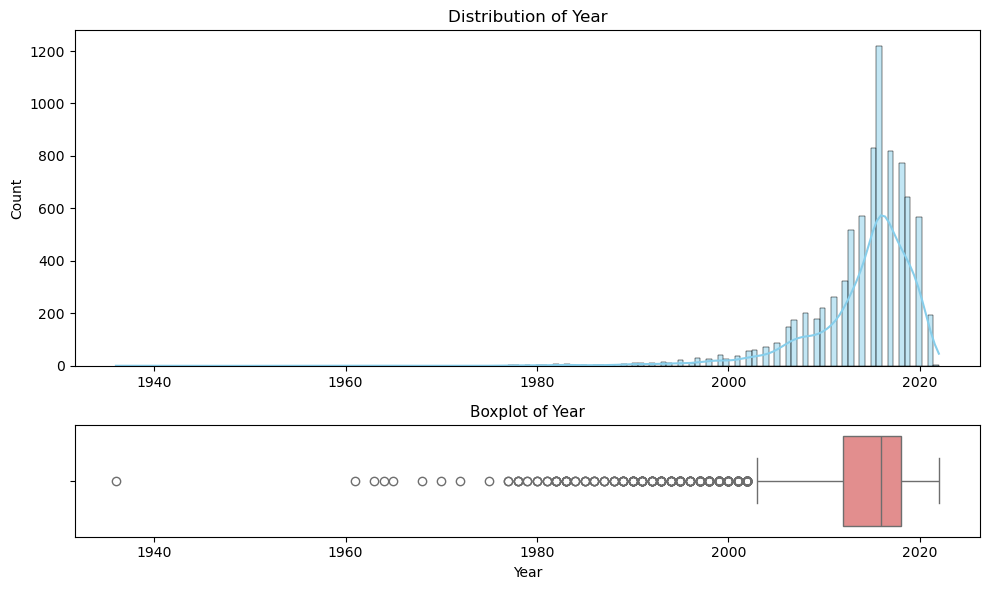

In [6]:
def check_normality(df, cols=None):
    """
    Function to examine numeric distribution normality:
    - Displays skewness & kurtosis
    - Shows histogram + KDE and boxplot for each column

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe
    cols : list (optional)
        List of columns to analyze. If None → all numeric columns.
    """

    # Create a copy to keep original data safe
    df_temp = df.copy()

    # Determine numeric columns
    if cols is None:
        cols = df_temp.select_dtypes(include=[np.number]).columns.tolist()

    # Temporarily convert columns to numeric (in case some are still object)
    for col in cols:
        df_temp[col] = pd.to_numeric(df_temp[col], errors='coerce')

    # Compute skewness & kurtosis
    normality_df = df_temp[cols].agg(['skew', 'kurtosis']).transpose()
    print("\n📊 Skewness & Kurtosis Summary:")
    display(normality_df)

    # Visualization for each column
    for col in cols:
        fig, axes = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [3, 1]})

        # Histogram + KDE
        sns.histplot(df_temp[col], kde=True, ax=axes[0], color='skyblue')
        axes[0].set_title(f'Distribution of {col}', fontsize=12)
        axes[0].set_xlabel('')

        # Boxplot
        sns.boxplot(x=df_temp[col], ax=axes[1], color='lightcoral')
        axes[1].set_title(f'Boxplot of {col}', fontsize=11)

        plt.tight_layout()
        plt.show()

# Run normality analysis for a specific column
check_normality(df, ['Year'])

Based on the visualization and statistical calculations, the distribution of the **vehicle production year (Year)** shows a **non-normal pattern** and is heavily **skewed toward newer vehicles**.

#### Visualization Results

* The **histogram** shows that most cars come from **recent production years**, especially within the **2014–2020** range.  
* Older vehicles appear in **very small numbers**, but still emerge as isolated points.  
* The **boxplot** reveals many **outliers on the older-year side**, representing older vehicles that are far fewer compared to modern cars.  

#### Distribution Statistics

* **Skewness = -2.62**  
  Indicates a **left-skewed distribution**, meaning the data is concentrated in recent years with a long tail toward older years.  

* **Kurtosis = 12.73**  
  Suggests a **highly peaked and extreme distribution**, with outliers located far from the majority of the data.


📊 Skewness & Kurtosis Summary:


,skew,kurtosis
Engine_Size,0.948518,0.599946


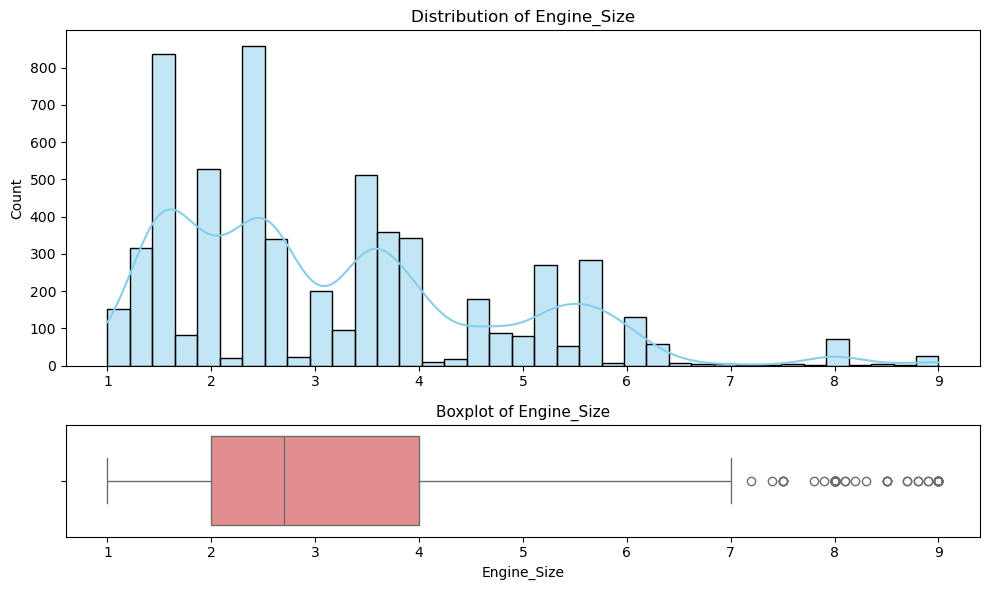

In [7]:
check_normality(df, ['Engine_Size'])

#### Visualization Results

* The **histogram** shows that most cars have engine capacities in the **2.0 – 4.0 liter** range.  
* Several **distribution peaks** are visible, reflecting popular engine sizes in the market (e.g., 2.0L, 2.5L, 3.0L, and 4.0L).  
* The **boxplot** indicates the presence of **outliers at higher engine capacities**, particularly above **7.0 liters**, which are typically associated with large or premium vehicles.  

#### Distribution Statistics

* **Skewness = 0.95**  
  Indicates a **right-skewed distribution**, meaning large-engine vehicles are less common compared to small–mid engine cars.  

* **Kurtosis = 0.60**  
  Suggests a **moderately flat distribution**, where outliers remain within a reasonable range and are not excessively extreme.


📊 Skewness & Kurtosis Summary:


,skew,kurtosis
Mileage,29.592851,1438.938083


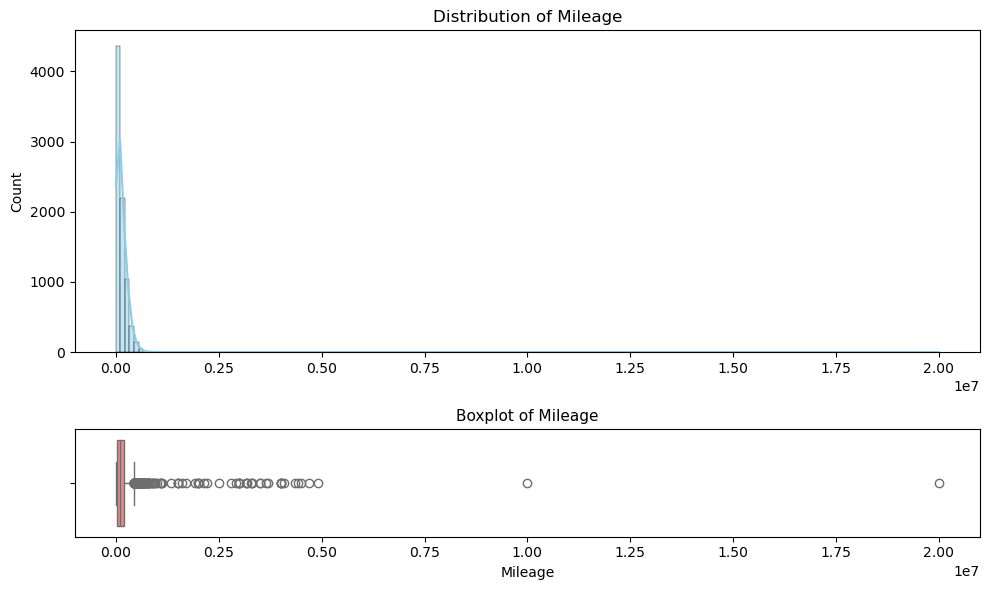

In [8]:
check_normality(df, ['Mileage'])

#### Visualization Results

* The **histogram** shows that most cars have **low to moderate mileage**, with data concentrated on the left side of the plot.  
* There is a **very long tail to the right**, indicating the presence of vehicles with extremely high mileage.  
* The **boxplot** reveals numerous **extreme outliers**, including mileage values far exceeding the majority of the data.  

#### Distribution Statistics

* **Skewness = 29.59**  
  Indicates a **highly right-skewed distribution**, meaning a small portion of the data has mileage values far greater than most vehicles.  

* **Kurtosis = 1438.94**  
  This extremely high value suggests a **very extreme distribution**, with many outliers located far from the central tendency.


📊 Skewness & Kurtosis Summary:


,skew,kurtosis
Price,3.691729,24.285586


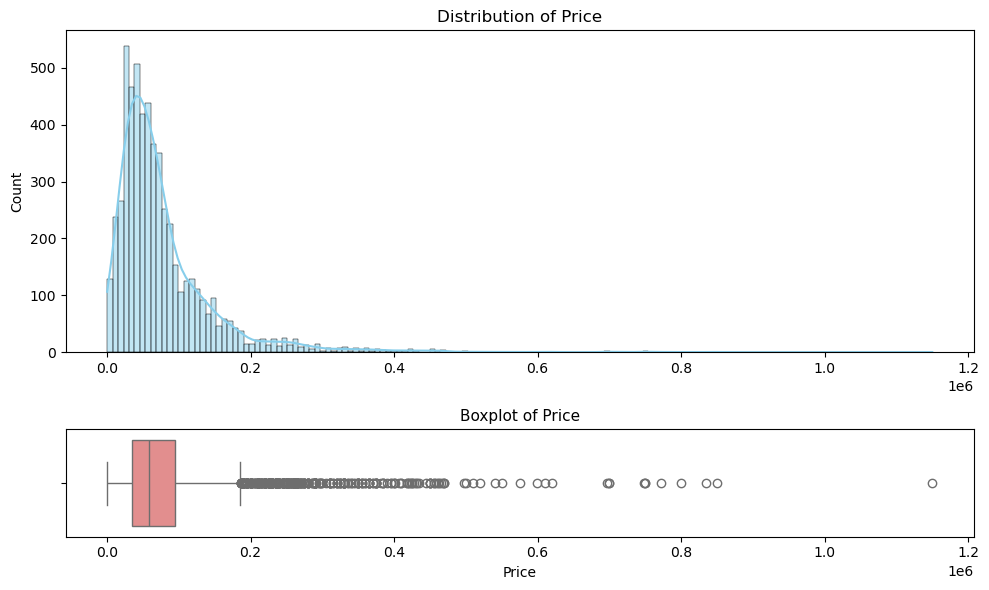

In [9]:
check_normality(df, ['Price'])

#### Visualization Results

* The **histogram** shows that most cars fall within the **low to mid price range**, with data concentrated on the left side of the chart.  
* A **long right tail** is visible, indicating the presence of very high-priced vehicles (premium segment).  
* The **boxplot** highlights numerous **outliers on the high-price side**, representing luxury cars or vehicles with special specifications.  

#### Distribution Statistics

* **Skewness = 3.69**  
  Indicates a **right-skewed distribution**, meaning high-priced cars are far less common than more affordable vehicles.  

* **Kurtosis = 24.29**  
  Suggests a **peaked distribution with many extreme values**, particularly in the higher price segment.

## 2.5 Handling Missing Values

In [10]:
df = df.copy()

# Impute Engine_Size using mode per (Type, Year)
engine_group_mode = (
    df.groupby(['Type', 'Year'])['Engine_Size']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

def fill_engine_size(row):
    if pd.notna(row['Engine_Size']):
        return row['Engine_Size']
    key = (row['Type'], row['Year'])
    val = engine_group_mode.get(key, np.nan)
    return val

df['Engine_Size'] = df.apply(fill_engine_size, axis=1)

# If NaN still exists, fill with global mode
if df['Engine_Size'].isna().sum() > 0:
    global_mode = df['Engine_Size'].mode().iloc[0]
    df['Engine_Size'].fillna(global_mode, inplace=True)

# Impute Gear_Type
if df['Gear_Type'].isna().sum() > 0:
    gear_mode = df['Gear_Type'].mode().iloc[0]
    df['Gear_Type'].fillna(gear_mode, inplace=True)

# For other categorical columns
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col].fillna('Unknown', inplace=True)

print('Missing values after imputation:')
df.isna().sum().sum()

Missing values after imputation:


np.int64(0)

#### Engine Size Imputation (Engine_Size)
Missing values in **Engine_Size** were filled using the **most frequent value (mode)** based on the combination of **car type (Type)** and **production year (Year)**. This approach was chosen because vehicles with the same type and year tend to share similar engine specifications.  
If no suitable value was found within that combination, the **global mode** was used as a fallback.

#### Transmission Type Imputation (Gear_Type)
Missing values in the **Gear_Type** column were filled using the **most common category** in the dataset. This is reasonable from a business perspective since most vehicles share the same transmission type.

#### Handling Other Categorical Columns
For other categorical columns with missing values, entries were replaced with the label **"Unknown"** so the data could still be processed by the model without removing rows.

## 2.6 Removing Irrelevant Columns

In [11]:
cols_to_drop = ['Link', 'Condition', 'Negotiable']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True, errors='ignore')
df.shape

(8248, 12)

The columns removed include:

- **Link**  
  Contains advertisement links and serves only as a data identifier, making it irrelevant for price prediction.  

- **Condition**  
  All entries have the same value (*Used*), so it does not provide additional informational variation.  

- **Negotiable**  
  This information does not directly influence the listed price value and may introduce bias into the modeling process.

## 2.7 Removing Duplicates

In [12]:
print('Number of duplicates before removal:', df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print('Number of rows after duplicate removal:', df.shape)

Number of duplicates before removal: 71
Number of rows after duplicate removal: (8177, 12)


Before removal, a total of **71 duplicate rows** were identified in the dataset. These duplicates could introduce bias into the analysis and modeling process if left untreated.  

After duplicate removal:
- The number of records decreased from **8,248 rows** to **8,177 rows**  
- The number of columns remained **12 columns**

## 2.8 Handling Outliers

In [13]:
df = df[pd.to_numeric(df['Price'], errors='coerce').notna()].copy()
df['Price'] = df['Price'].astype(float)

print('Number of rows after ensuring Price is numeric:', df.shape)

def remove_outliers_iqr(df, col, k=1.5, verbose=True):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - k * IQR
    upper_bound = Q3 + k * IQR

    mask = (df[col] >= lower_bound) & (df[col] <= upper_bound)
    df_clean = df[mask].copy()

    if verbose:
        print(f'[{col}] Lower bound: {lower_bound:.2f}, upper bound: {upper_bound:.2f}')
        print(f'[{col}] Rows before: {df.shape[0]}, after: {df_clean.shape[0]}')
        print('-' * 50)

    return df_clean  # <-- return dataframe only

df = remove_outliers_iqr(df, 'Year')
df = remove_outliers_iqr(df, 'Engine_Size')
df = remove_outliers_iqr(df, 'Mileage')
df = remove_outliers_iqr(df, 'Price')

Number of rows after ensuring Price is numeric: (5593, 12)
[Year] Lower bound: 2005.50, upper bound: 2025.50
[Year] Rows before: 5593, after: 5318
--------------------------------------------------
[Engine_Size] Lower bound: -1.00, upper bound: 7.00
[Engine_Size] Rows before: 5318, after: 5274
--------------------------------------------------
[Mileage] Lower bound: -144000.00, upper bound: 368000.00
[Mileage] Rows before: 5274, after: 5127
--------------------------------------------------
[Price] Lower bound: -52000.00, upper bound: 188000.00
[Price] Rows before: 5127, after: 4781
--------------------------------------------------


To reduce the impact of unrealistic extreme values, outliers were removed using the **Interquartile Range (IQR)** method on several key numeric columns. This approach retains data within a reasonable range based on the distribution. Outliers were removed sequentially from the following columns:

- **Year**  
  - Acceptable range: 2005.5 – 2025.5  
  - Number of records decreased from **5,593** to **5,318**

- **Engine_Size**  
  - Acceptable range: -1.0 – 7.0  
  - Number of records decreased from **5,318** to **5,274**

- **Mileage**  
  - Acceptable range: -144,000 – 368,000  
  - Number of records decreased from **5,274** to **5,127**

- **Price**  
  - Acceptable range: -52,000 – 188,000  
  - Number of records decreased from **5,127** to **4,781**

## 2.9 Data Type Conversion

In [14]:
# =========================
# 1. Numeric columns
# =========================
numeric_cols = ['Year', 'Mileage', 'Engine_Size', 'Price']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# =========================
# 2. Categorical columns
# =========================
categorical_cols = [
    'Make', 'Type', 'Origin', 'Color',
    'Options', 'Fuel_Type', 'Gear_Type', 'Region'
]
for col in categorical_cols:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4781 entries, 0 to 8176
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Make         4781 non-null   category
 1   Type         4781 non-null   category
 2   Year         4781 non-null   int64   
 3   Origin       4781 non-null   category
 4   Color        4781 non-null   category
 5   Options      4781 non-null   category
 6   Engine_Size  4781 non-null   float64 
 7   Fuel_Type    4781 non-null   category
 8   Gear_Type    4781 non-null   category
 9   Mileage      4781 non-null   int64   
 10  Region       4781 non-null   category
 11  Price        4781 non-null   float64 
dtypes: category(8), float64(2), int64(2)
memory usage: 244.6 KB


#### Numeric Columns
Numeric columns were converted to numeric data types so they can be used in statistical calculations and regression modeling.

The numeric columns include:
- **Year** → vehicle production year  
- **Mileage** → vehicle mileage  
- **Engine_Size** → engine capacity  
- **Price** → vehicle price (target)  

All numeric columns were successfully converted without introducing additional missing values.

#### Categorical Columns
Categorical columns were converted to the **category** data type to:
- reduce memory usage  
- clearly indicate categorical nature instead of free text  
- facilitate encoding in the next stage  

The categorical columns include:
- **Make**, **Type**, **Origin**  
- **Color**, **Options**  
- **Fuel_Type**, **Gear_Type**  
- **Region**  

#### Dataset Condition After Adjustment
- Number of records: **4,781 rows**  
- Number of columns: **12 columns**  
- No missing values remain  
- Data type composition:
  - 8 categorical columns  
  - 4 numeric columns

## 2.10 Feature Engineering (Non-Target)

In [15]:
from datetime import datetime
import numpy as np

# =========================
# Feature Engineering
# =========================
CURRENT_YEAR = 2025  # Assumption

# Ensure numeric data types
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['Mileage'] = pd.to_numeric(df['Mileage'], errors='coerce')

# Calculate car age
df['Car_Age'] = CURRENT_YEAR - df['Year']
df['Car_Age'] = df['Car_Age'].clip(lower=0)

# Calculate mileage per year (avoid division by zero)
df['Mileage_per_Year'] = df['Mileage'] / (df['Car_Age'] + 1)

#### Car Age (Car_Age)
The **Car_Age** feature was created by calculating the difference between the **current year (2025)** and the **vehicle’s production year**. This feature provides a more intuitive representation than using the raw production year.

- Car age values are constrained to avoid negative numbers.  
- In general, a higher **Car_Age** is associated with a lower vehicle price.  

#### Mileage per Year (Mileage_per_Year)
The **Mileage_per_Year** feature was calculated by dividing the **total mileage** by **car age + 1** to prevent division by zero.

This feature helps distinguish between:
- older cars with light usage  
- relatively newer cars with heavy usage  

which often have different pricing implications.

## 2.11 Exploratory Data Analysis

### 2.11.1 Univariate Analysis


📊 Skewness & Kurtosis Summary:


,skew,kurtosis
Engine_Size,0.664139,-0.46971


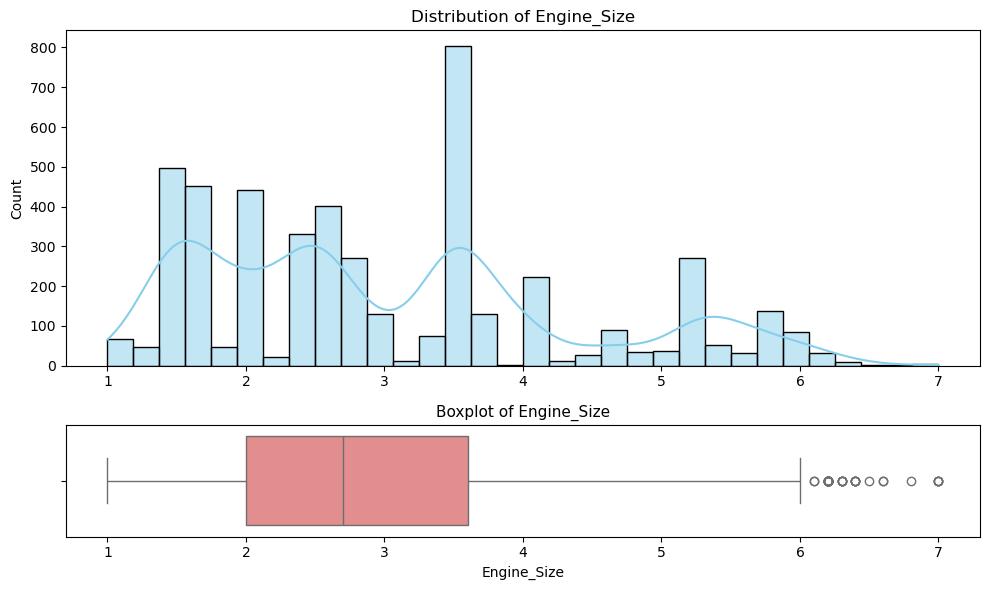

In [16]:
check_normality(df, ['Engine_Size'])

#### Visualization Results
- The **histogram** shows that most cars have engine capacities within the **2.0 – 4.0 liter** range, which is the most common engine size in the market.  
- The distribution appears **cleaner and more concentrated** compared to the pre-cleaning stage.  
- The **boxplot** still shows a few extreme values on the right side (large engines), but they are significantly fewer and remain within a reasonable business range.  

#### Distribution Statistics
- **Skewness = 0.66**  
  Indicates the distribution is still slightly **right-skewed**, but much more balanced than the initial condition.  

- **Kurtosis = -0.47**  
  Suggests a relatively **flat distribution**, without extreme peaks or heavy tails.  

#### Business Interpretation
- This pattern reflects a more realistic market condition, where small to mid-size engine vehicles dominate, while large-engine cars represent only a small portion.  
- The remaining extreme values correspond to the **large or premium vehicle segment**, which remains relevant for price prediction.


📊 Skewness & Kurtosis Summary:


,skew,kurtosis
Mileage,0.698284,-0.157377


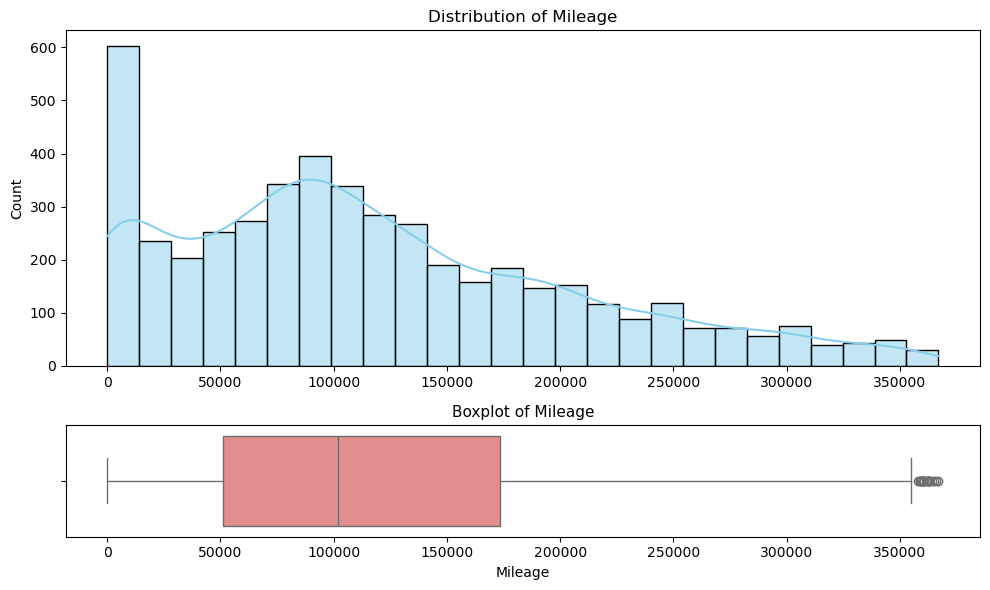

In [17]:
check_normality(df, ['Mileage'])

#### Visualization Results
- The **histogram** shows a more even mileage distribution, with most cars falling within the **50,000 – 150,000 km** range.  
- The distribution appears **smoother and more concentrated**, without the extremely long tail observed in the raw data.  
- The **boxplot** still displays some higher values on the right side, but they remain within a **reasonable business range**.  

#### Distribution Statistics
- **Skewness = 0.70**  
  Indicates the distribution is still slightly **right-skewed**, but much more balanced compared to the pre-cleaning stage.  

- **Kurtosis = -0.16**  
  Suggests a relatively **flat distribution**, without excessive concentration of extreme values.  

#### Business Interpretation
- This pattern reflects a realistic market condition where vehicles with moderate mileage dominate.  
- High-mileage cars are still present, but no longer distort the overall data distribution.


📊 Skewness & Kurtosis Summary:


,skew,kurtosis
Price,0.931783,0.340135


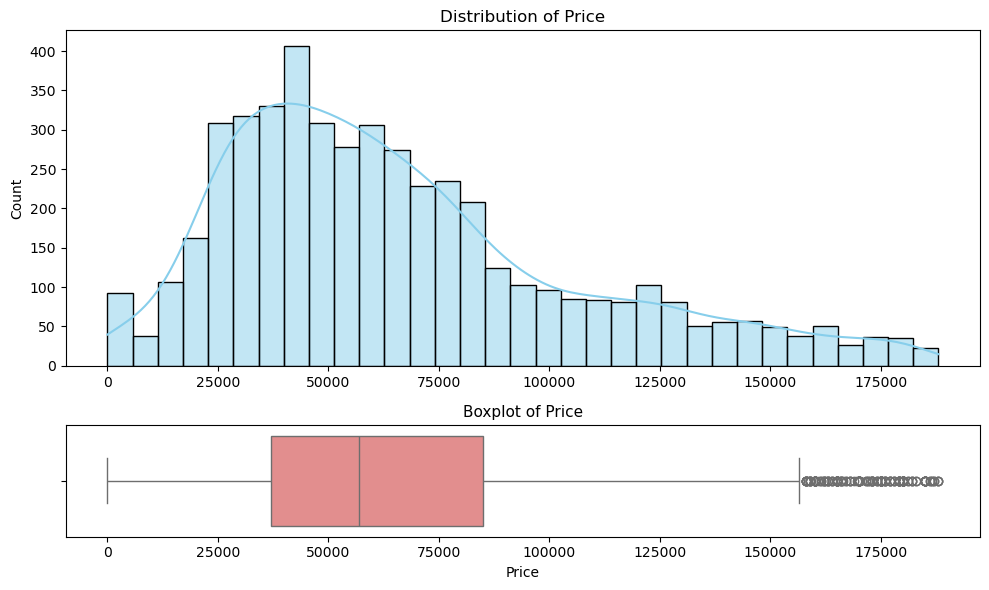

In [18]:
check_normality(df, ['Price'])

#### Visualization Results
- The **histogram** shows that most cars fall within the **mid-price range**, with the main concentration around **30,000 – 80,000 SAR**.  
- The distribution appears **smoother and more controlled**, without the extremely long tail present in the raw data.  
- The **boxplot** still displays several higher price values on the right side, but they remain within a **reasonable business range** and represent vehicles in the premium segment.  

#### Distribution Statistics
- **Skewness = 0.93**  
  Indicates the distribution is still slightly **right-skewed**, but much more balanced compared to the pre-cleaning stage.  

- **Kurtosis = 0.34**  
  Suggests a relatively **normal and moderately peaked distribution**, with a controlled number of outliers.  

#### Business Interpretation
- This distribution reflects realistic market conditions, where affordable to mid-range vehicles dominate transactions.  
- Higher-priced vehicles remain present as part of specific segments, but no longer distort the overall dataset.

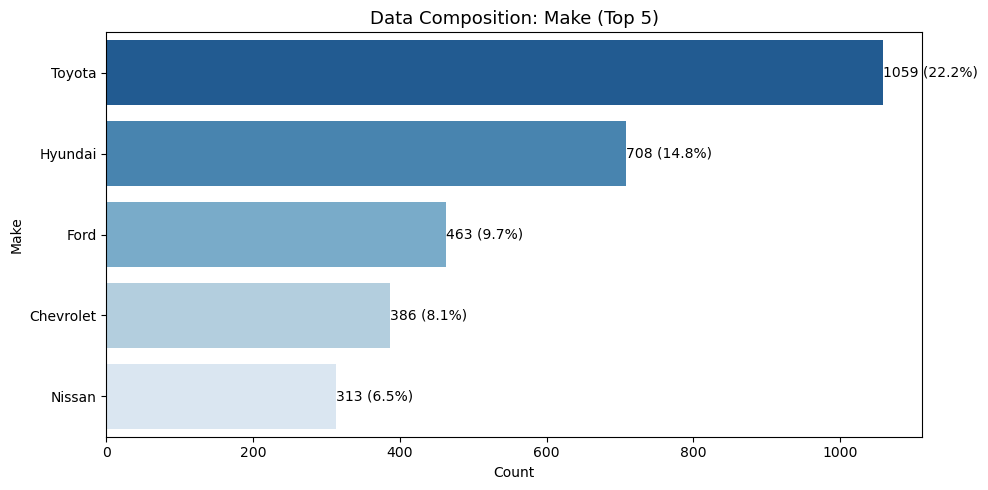

In [19]:
def countplot_categorical(
    df,
    cols=None,
    top_n=5,
    figsize=(10, 5),
    show_percent=True
):
    """
    Display countplots for categorical (non-numeric) columns.
    """

    # If columns are not specified, select all categorical columns
    if cols is None:
        cols = df.select_dtypes(include='object').columns.tolist()

    for col in cols:
        data = (
            df[col]
            .value_counts(dropna=False)
            .head(top_n)
            .reset_index()
        )
        data.columns = [col, 'Count']
        data['Percentage'] = (data['Count'] / len(df)) * 100

        plt.figure(figsize=figsize)
        sns.barplot(
            data=data,
            y=col,
            x='Count',
            order=data[col],
            palette='Blues_r'
        )

        # 👉 Title with Top-N info
        plt.title(
            f'Data Composition: {col} (Top {top_n})',
            fontsize=13
        )
        plt.xlabel('Count')
        plt.ylabel(col)

        # Add count & percentage labels
        for i, row in data.iterrows():
            label = f"{row['Count']}"
            if show_percent:
                label += f" ({row['Percentage']:.1f}%)"
            plt.text(
                row['Count'],
                i,
                label,
                va='center',
                fontsize=10
            )

        plt.tight_layout()
        plt.show()

countplot_categorical(
    df,
    cols=['Make'],
    top_n=5
)

#### **Key Insights**
* **Market Dominance:** **Toyota** is the most dominant brand in the dataset, accounting for **22.2%** of the total records. This is significantly higher (≈7.4% gap) than Hyundai in second place.  
* **Data Concentration:** The top five brands collectively contribute around **61.3%** of the dataset, indicating that the vehicle population is highly concentrated among a few major manufacturers.  
* **Distribution Pattern:** There is a noticeable drop after Hyundai, with Ford, Chevrolet, and Nissan each contributing **below 10%**.  

#### **Technical Conclusion**
The visualization using a *horizontal bar chart* with percentage labels provides clear and effective comparison across categories, enabling quick and accurate interpretation of proportional differences.

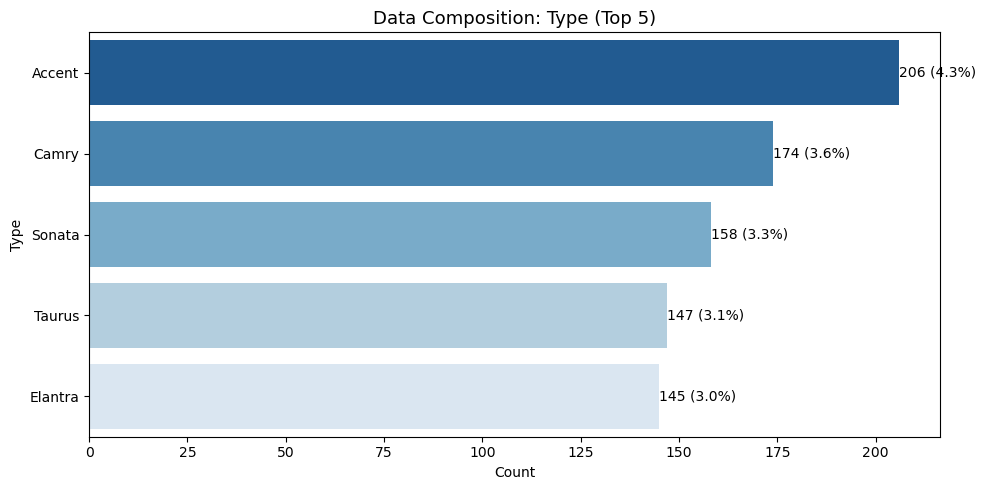

In [20]:
countplot_categorical(
    df,
    cols=['Type'],
    top_n=5
)

#### **Key Insights**
* **Most Popular Model:** **Accent** is the most frequent vehicle type in the dataset with **206 units (4.3%)**.  
* **Tighter Competition:** Unlike the brand distribution (Make), the type category appears more competitive and evenly spread. The gap between first place (Accent) and second place (**Camry**, 3.6%) is only **0.7%**.  
* **Model Representation:** The top five models (Accent, Camry, Sonata, Taurus, and Elantra) fall within a very close percentage range of **3.0% to 4.3%**.  
* **Low Concentration:** Together, these five types contribute only about **17.3%** of the total dataset, indicating that model variation is much more diverse than brand variation.

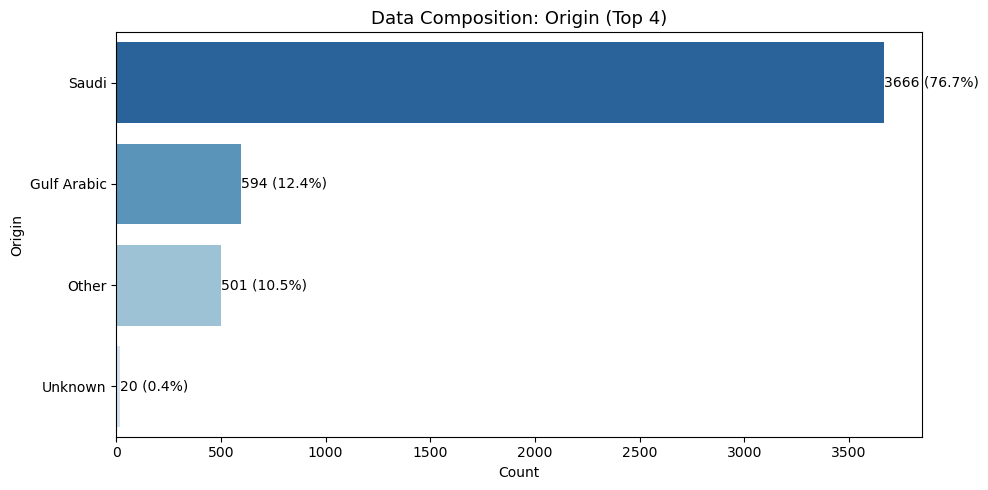

In [21]:
countplot_categorical(
    df,
    cols=['Origin'],
    top_n=df['Origin'].nunique()
)

#### **Key Insights**
* **Local Dominance:** **Saudi** is the most dominant vehicle origin by a large margin, with **3,666 units (76.7%)**. This indicates that most records come from the Saudi domestic market.  
* **Regional Market:** **Gulf Arabic** ranks second with **594 units (12.4%)**, showing contributions from neighboring Gulf countries.  
* **Other Categories:** The **Other** category accounts for **10.5% (501 units)**, while **Unknown** is minimal at only **0.4% (20 units)** of the dataset.  
* **Distribution Gap:** There is a stark contrast between the first-ranked category (Saudi) and the others, with a percentage gap of more than **64%** between the first and second positions.

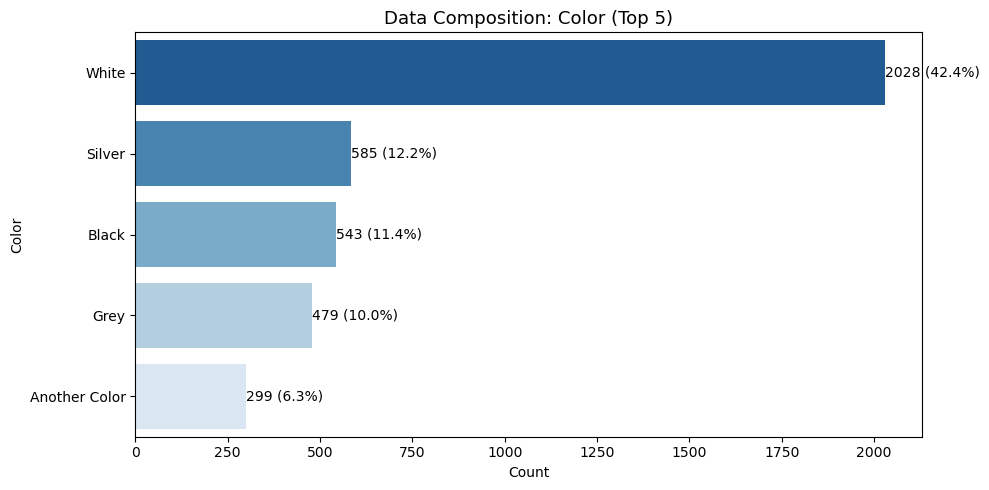

In [22]:
countplot_categorical(
    df,
    cols=['Color'],
    top_n=5
)

#### **Key Insights**
* **Favorite Color:** **White** is overwhelmingly dominant with **2,028 units (42.4%)**, accounting for nearly half of the dataset.  
* **Neutral Color Dominance:** Other neutral colors such as **Silver (12.2%)**, **Black (11.4%)**, and **Grey (10.0%)** follow with relatively balanced proportions.  
* **Limited Color Variety:** The **Another Color** category represents only **6.3% (299 units)**, indicating that most vehicles in the dataset use standard industry colors.  
* **Percentage Gap:** There is a significant gap (over **30%**) between white and the second most popular color (Silver), highlighting a strong market preference for specific colors.

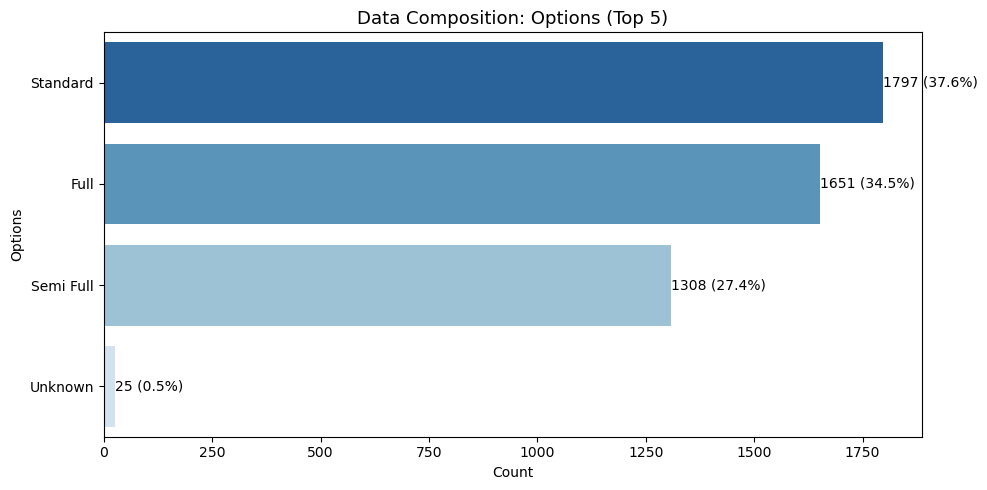

In [23]:
countplot_categorical(
    df,
    cols=['Options'],
    top_n=5
)

#### **Key Insights**
* **Most Common Variant:** The **Standard** variant is the most prevalent, with **1,797 units (37.6%)**.  
* **Strong Demand for Full Features:** The **Full** variant closely follows in second place with **1,651 units (34.5%)**.  
* **Mid-Level Variant:** The **Semi Full** type contributes a significant **27.4% (1,308 units)**, indicating a sizable market segment for mid-range feature packages.  
* **Unknown Category:** Only a very small portion of data falls under **Unknown**, accounting for **0.5% (25 units)**.  
* **Balanced Distribution:** Overall, the distribution among *Standard*, *Full*, and *Semi Full* is relatively competitive compared to other categories such as *Origin* or *Color*.

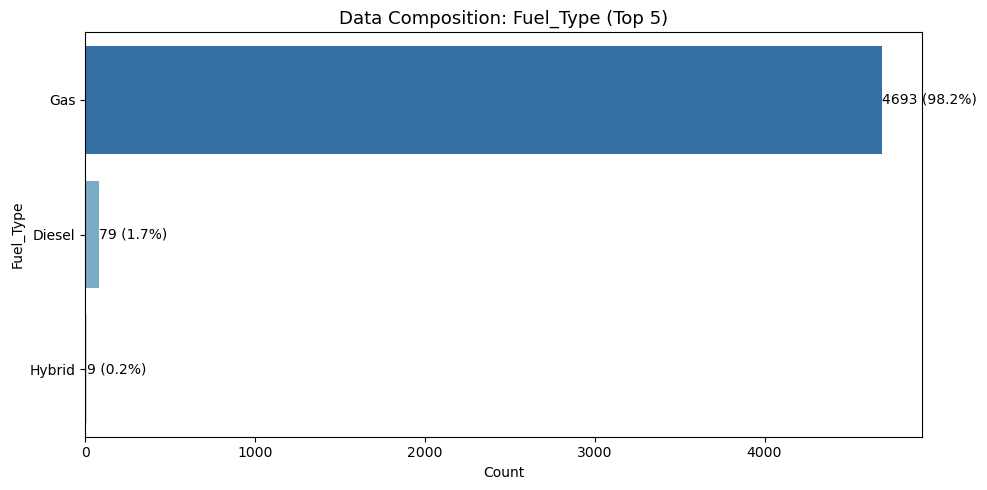

In [24]:
countplot_categorical(
    df,
    cols=['Fuel_Type'],
    top_n=5
)

#### **Key Insights**
* **Overwhelming Gas Dominance:** **Gas-powered** vehicles dominate the dataset with **4,693 units (98.2%)**.  
* **Low Diesel Presence:** **Diesel** fuel type represents only a very small share at **1.7% (79 units)**.  
* **Minimal Hybrid Segment:** **Hybrid** vehicles are nearly insignificant in this dataset, with just **9 units (0.2%)**.  
* **Energy Source Uniformity:** These findings indicate that the vehicle market represented in this dataset relies almost entirely on gas fuel, with very limited alternatives.

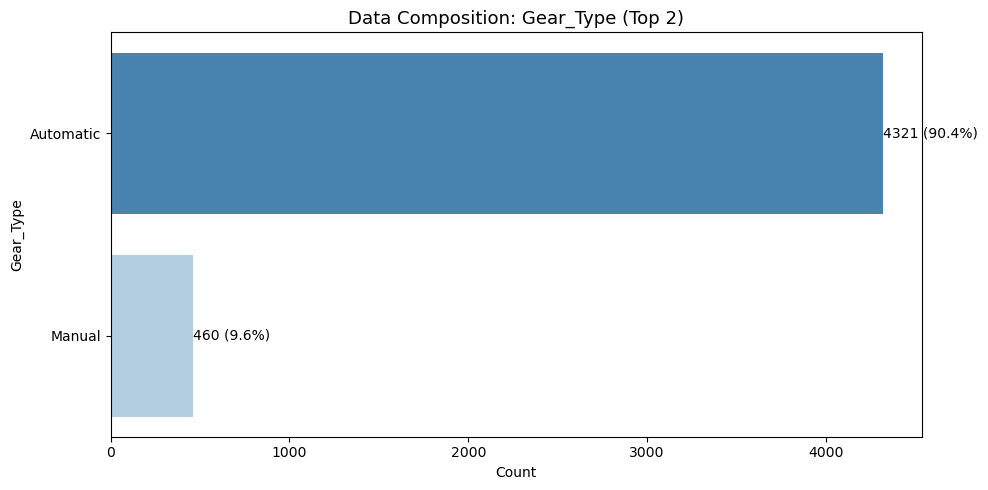

In [25]:
countplot_categorical(
    df,
    cols=['Gear_Type'],
    top_n=df['Gear_Type'].nunique()
)

#### **Key Insights**
* **Automatic Transmission Dominance:** Vehicles with **Automatic** transmission overwhelmingly dominate the market with **4,321 units (90.4%)**.  
* **Manual Transmission Share:** **Manual** transmission accounts for only a small portion of the dataset at **9.6% (460 units)**.  
* **Technology Preference:** The high percentage of automatic transmission suggests a strong consumer preference for driving comfort or reflects modern vehicle specifications commonly available in the region.  
* **Significant Gap:** There is a stark difference in volume (over **80%**) between the two transmission types, reinforcing automatic transmission as the primary standard.

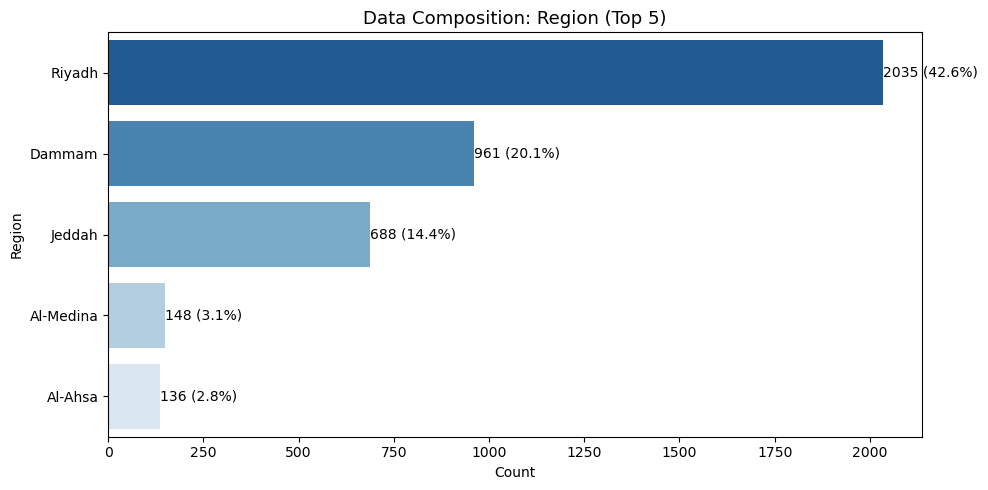

In [26]:
countplot_categorical(
    df,
    cols=['Region'],
    top_n=5
)

#### **Key Insights**
* **Primary Activity Hub:** **Riyadh** dominates as the region with the highest number of listings, totaling **2,035 units (42.6%)**.  
* **Other Major Economic Areas:** **Dammam** and **Jeddah** rank second and third with **961 units (20.1%)** and **688 units (14.4%)**, respectively.  
* **Geographic Concentration:** The top three regions (Riyadh, Dammam, Jeddah) collectively account for more than **77%** of the dataset, indicating a strong market concentration in major cities.  
* **Additional Regions:** **Al-Medina (3.1%)** and **Al-Ahsa (2.8%)** complete the top five, contributing significantly less than the leading metropolitan areas.

### 2.11.2 Bivariate Analysis

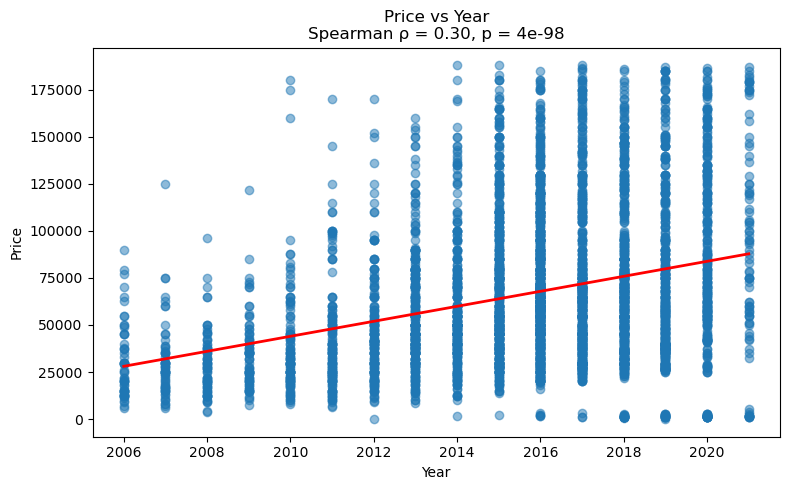

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# -----------------------------
# Numeric features (X) & target (y)
# -----------------------------
num_features = ['Year', 'Engine_Size', 'Mileage']
target = 'Price'

# Ensure numeric format
df_plot = df[num_features + [target]].copy()
for col in df_plot.columns:
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')

df_plot = df_plot.dropna()

# -----------------------------
# Scatter function + trendline
# -----------------------------
def scatter_with_trendline(df, x_col, y_col):
    x = df[x_col]
    y = df[y_col]

    # Compute Spearman correlation (optional but informative)
    rho, p = spearmanr(x, y)

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, alpha=0.5)

    # Red linear trendline
    z = np.polyfit(x, y, 1)
    p_line = np.poly1d(z)
    plt.plot(
        x.sort_values(),
        p_line(x.sort_values()),
        color='red',
        linewidth=2
    )

    plt.title(
        f'{y_col} vs {x_col}\n'
        f'Spearman ρ = {rho:.2f}, p = {p:.2g}',
        fontsize=12
    )
    plt.xlabel(x_col)
    plt.ylabel(y_col)

    plt.tight_layout()
    plt.show()

scatter_with_trendline(
    df_plot,
    x_col='Year',
    y_col='Price'
)

#### **Key Insights**
* **Upward Price Trend:** A clear positive trend is observed where vehicle prices tend to increase with newer production years.  
* **Spearman Correlation:** The **Spearman ρ = 0.30** indicates a weak to moderate positive correlation.  
* **Statistical Significance:** The extremely small **p-value = 4e-98** (far below 0.05) confirms that the relationship between year and price is highly statistically significant and not due to chance.  
* **Wide Price Variability:** Despite the upward red regression line, a wide spread of data points is visible in newer years (2015–2021). This suggests that prices vary considerably within the same year, likely influenced by other factors such as brand, model, or vehicle condition.  
* **Data Concentration:** A noticeable increase in data density appears from 2012 onward, indicating that the dataset is dominated by vehicles produced within the last decade.

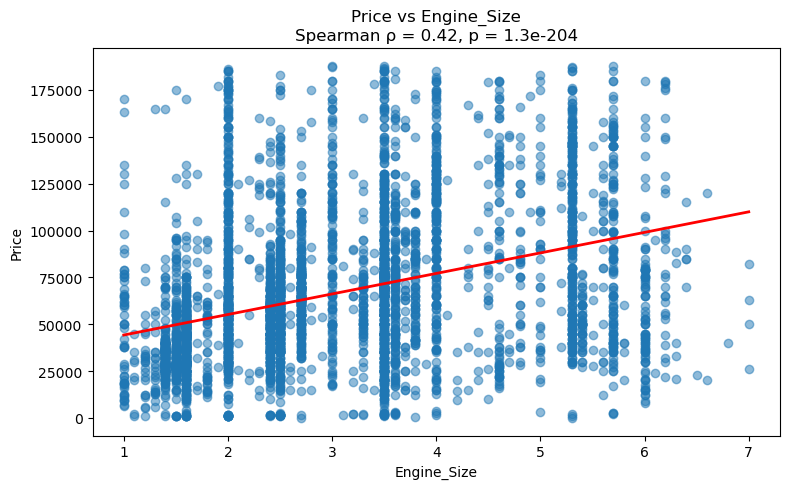

In [28]:
scatter_with_trendline(
    df_plot,
    x_col='Engine_Size',
    y_col='Price'
)

#### **Key Insights**
* **Strongest Positive Correlation:** The relationship between engine size and price has a **Spearman ρ = 0.42**, indicating a moderate positive correlation that is stronger than the relationship between production year and price.  
* **High Statistical Significance:** The extremely low **p-value = 1.3e-204** confirms that this relationship is highly statistically significant within the dataset.  
* **Engine Capacity Trend:** The red regression line shows that, in general, larger **engine sizes** are associated with higher vehicle prices.  
* **Engine Size Distribution:** Most vehicles are concentrated within the **1.0 to 4.0 liter** range. Although some vehicles reach up to **7.0 liters**, they are much less frequent (sparser data points).  
* **Price Variability at Larger Engines:** At certain engine capacities (e.g., 3.5 or 5.3 liters), a strong vertical spread of prices is observed, indicating that vehicles with the same engine size can still vary greatly in price depending on factors such as brand or condition.

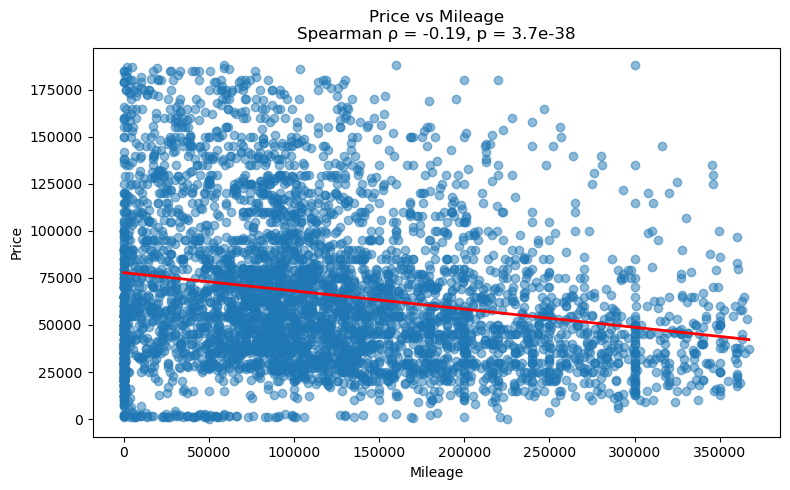

In [29]:
scatter_with_trendline(
    df_plot,
    x_col='Mileage',
    y_col='Price'
)

#### **Key Insights**
* **Negative Correlation:** The relationship between mileage and price shows a **Spearman ρ = -0.19**, indicating a weak negative correlation where vehicle prices generally decrease as mileage increases.  
* **Statistical Significance:** The very low **p-value = 3.7e-38** suggests that, despite the weak correlation, this relationship is highly statistically significant within the dataset.  
* **Price Depreciation:** The downward red regression line confirms the depreciation effect, where accumulated usage (kilometers driven) reduces vehicle value.  
* **Outliers and High Variability:** Many data points with low mileage (near 0) exhibit a wide price range—from very cheap to very expensive. This indicates that for “like-new” or lightly used vehicles, other factors such as brand or model play a stronger role than mileage alone.  
* **Mileage Range Concentration:** Most vehicles fall within the **0 to 200,000 km** mileage range, with data density decreasing beyond that threshold.

## 2.12 Save Clean Dataset

In [30]:
df.to_csv('../Datasets/UsedCarsSA_Clean.csv', index=False)
print('Clean dataset saved successfully!')

Clean dataset saved successfully!
